In [1]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from dateutil.parser import parse
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from hurst import compute_Hc
from datetime import date
import os
import datetime

In [2]:
# Import Data
df = pd.read_csv('NCSC-2014-2023.csv',index_col=['creation_date'],encoding='latin_1')
df.index = pd.to_datetime(df.index, origin='unix',unit='s')
df.insert(3,"Count",[1.0]*(int(len(df))))
df.head()

,id,version,title,Count,CVEs,probability_level,probability_matrix,damage_level,damage_matrix
creation_date,,,,,,,,,
2019-01-02,NCSC-2019-0001,1.0,Kwetsbaarheid verholpen in F5 BIG-IP,1.0,['CVE-2018-17539'],medium,"{'standard': 3, 'complexity': 1, 'access': 6, ...",high,"{'privesc': '0', 'dos': '2', 'remrights': '0',..."
2019-01-02,NCSC-2019-0002,1.0,Kwetsbaarheid verholpen in GitLab,1.0,['CVE-2018-20493'],medium,"{'standard': 3, 'complexity': 2, 'access': 6, ...",high,"{'privesc': '0', 'dos': '0', 'remrights': '0',..."
2019-01-02,NCSC-2019-0003,1.0,Kwetsbaarheden verholpen in NetIQ (voorheen No...,1.0,"['CVE-2018-17950', 'CVE-2018-17952']",medium,"{'standard': 3, 'complexity': 1, 'access': 4, ...",medium,"{'privesc': '1', 'dos': '0', 'remrights': '0',..."
2019-01-02,NCSC-2019-0004,1.0,Kwetsbaarheden gevonden in Buffalo NAS,1.0,"['CVE-2018-13318', 'CVE-2018-13319', 'CVE-2018...",medium,"{'standard': 3, 'complexity': 2, 'access': 4, ...",high,"{'privesc': '1', 'dos': '0', 'remrights': '0',..."
2019-01-02,NCSC-2019-0005,1.0,Kwetsbaarheden verholpen in FreeBSD NFS Server,1.0,"['CVE-2018-17157', 'CVE-2018-17158', 'CVE-2018...",medium,"{'standard': 3, 'complexity': 2, 'access': 4, ...",high,"{'privesc': '0', 'dos': '2', 'remrights': '0',..."


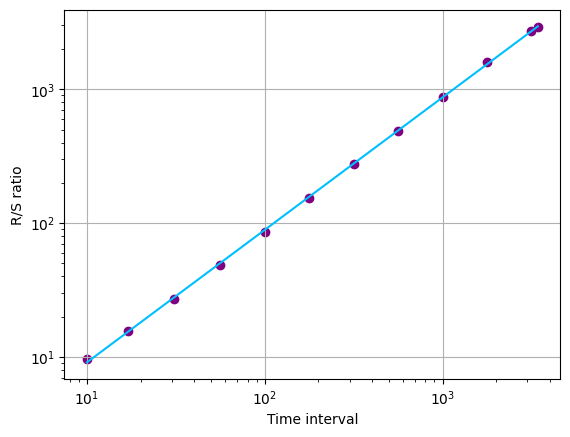

H=0.9897, c=0.9341


In [3]:
#Examine the data with the Hurst component to convinces ourselves this is possible (and lo0k at different timeframes of possibility)
H, c, data = compute_Hc(df['Count'].resample('D').sum(), kind='change',simplified=True)
# Plot
f, ax = plt.subplots()
ax.plot(data[0], c*data[0]**H, color="deepskyblue")
ax.scatter(data[0], data[1], color="purple")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time interval')
ax.set_ylabel('R/S ratio')
ax.grid(True)
plt.show()

print("H={:.4f}, c={:.4f}".format(H,c))

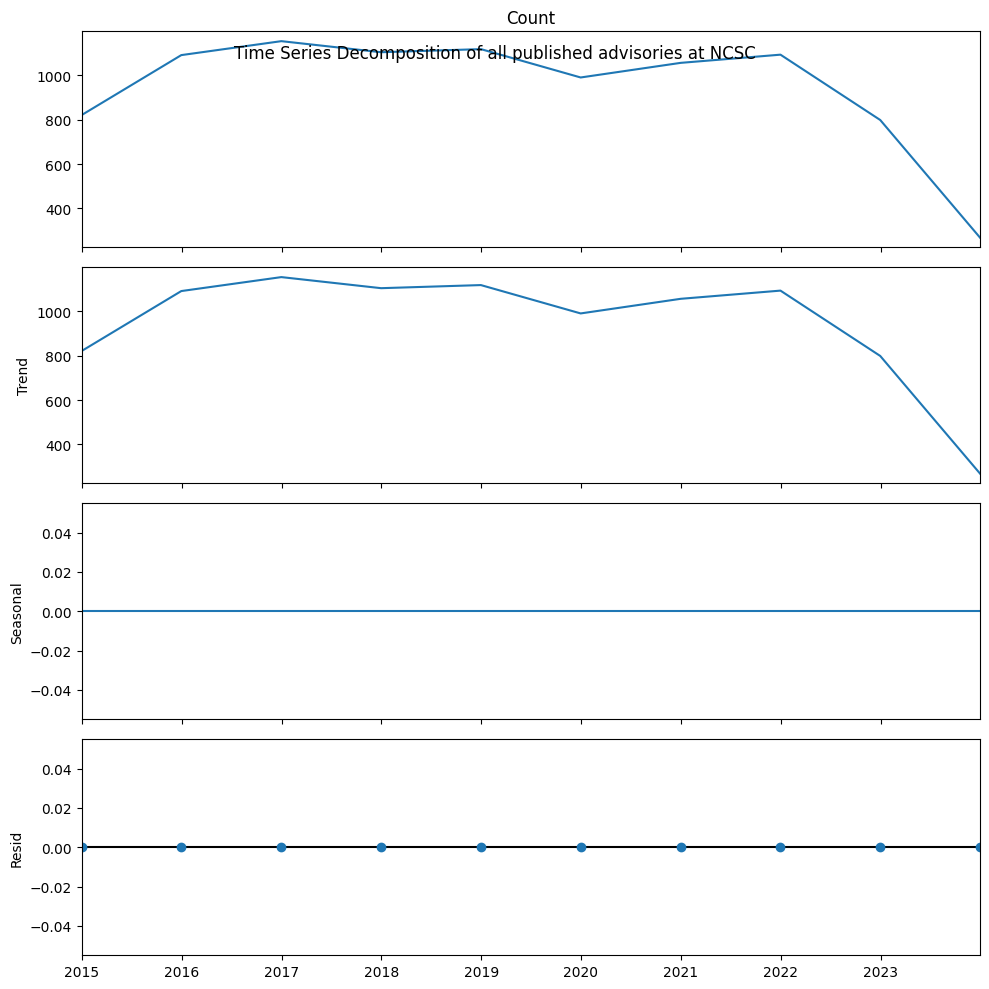

In [4]:
# Decompose 
result = seasonal_decompose(df['Count'].resample('Y').sum(), model='additive', extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (10,10)})
result.plot().suptitle('Time Series Decomposition of all published advisories at NCSC', y=0.95)
plt.show()

In [5]:
len(df['Count'].resample('M').sum())

114

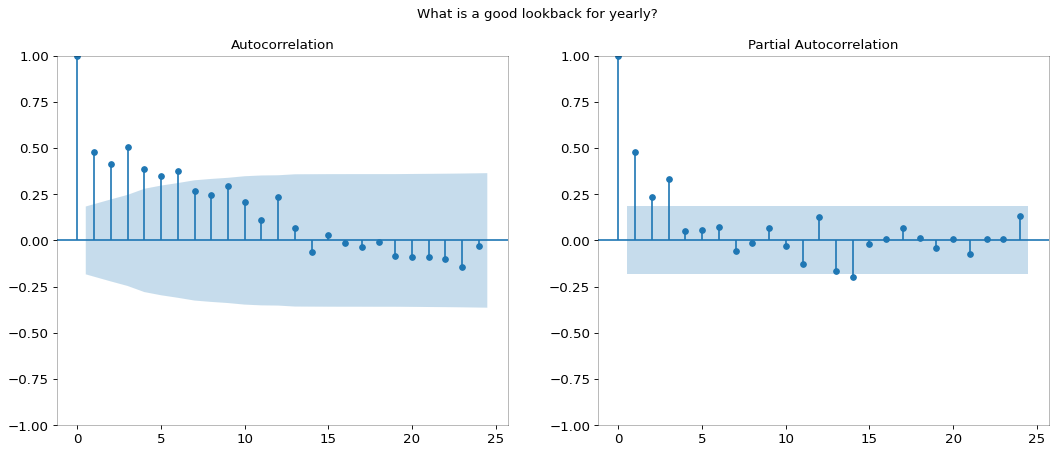

In [6]:
# Import Data
#df = all_vulns

# Draw Plot
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6), dpi= 80)
plot_acf(df['Count'].resample('M').sum().tolist(), ax=ax1, lags=24)
plot_pacf(df['Count'].resample('M').sum().tolist(), ax=ax2, lags=24)

# Decorate
# lighten the borders
ax1.spines["top"].set_alpha(.3); ax2.spines["top"].set_alpha(.3)
ax1.spines["bottom"].set_alpha(.3); ax2.spines["bottom"].set_alpha(.3)
ax1.spines["right"].set_alpha(.3); ax2.spines["right"].set_alpha(.3)
ax1.spines["left"].set_alpha(.3); ax2.spines["left"].set_alpha(.3)

# font size of tick labels
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
fig.suptitle("What is a good lookback for yearly?")
plt.show()

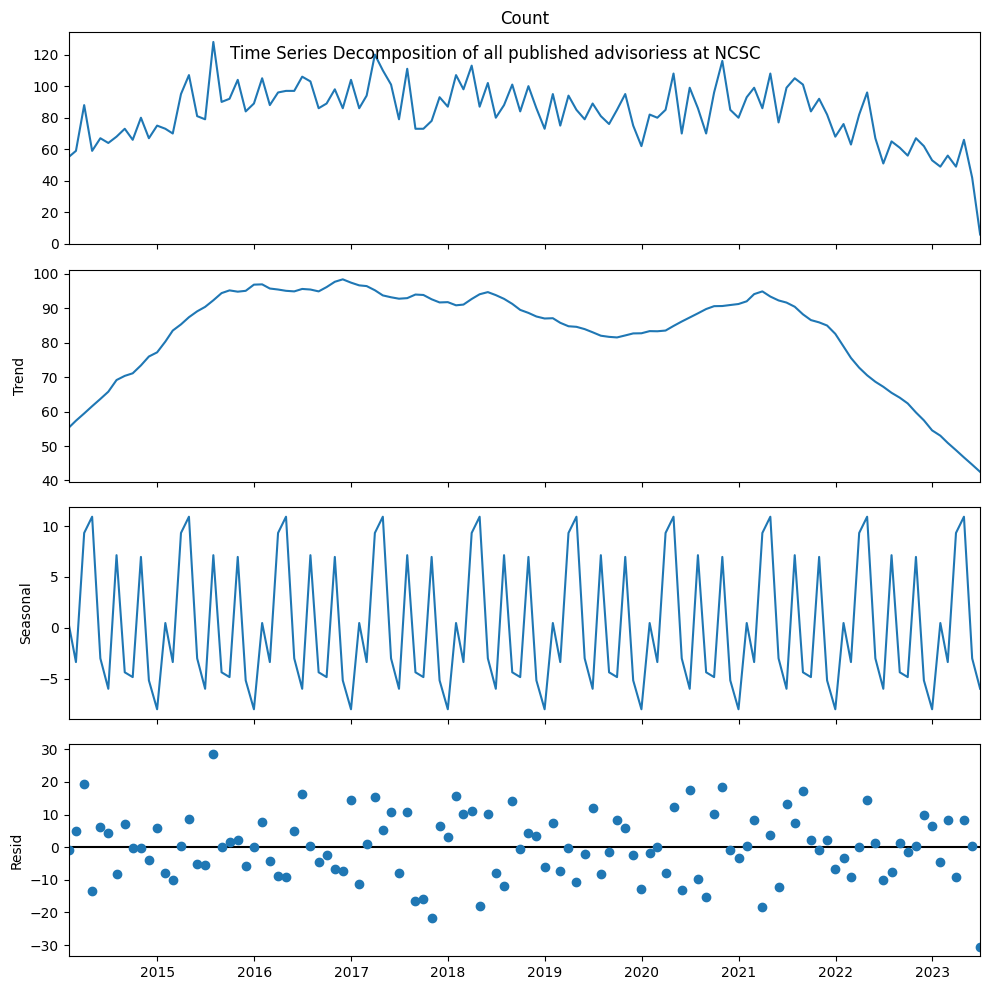

In [7]:
# Decompose 
result = seasonal_decompose(df['Count'].resample('M').sum(), model='additive', extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (10,10)})
result.plot().suptitle('Time Series Decomposition of all published advisoriess at NCSC', y=0.95)
plt.show()

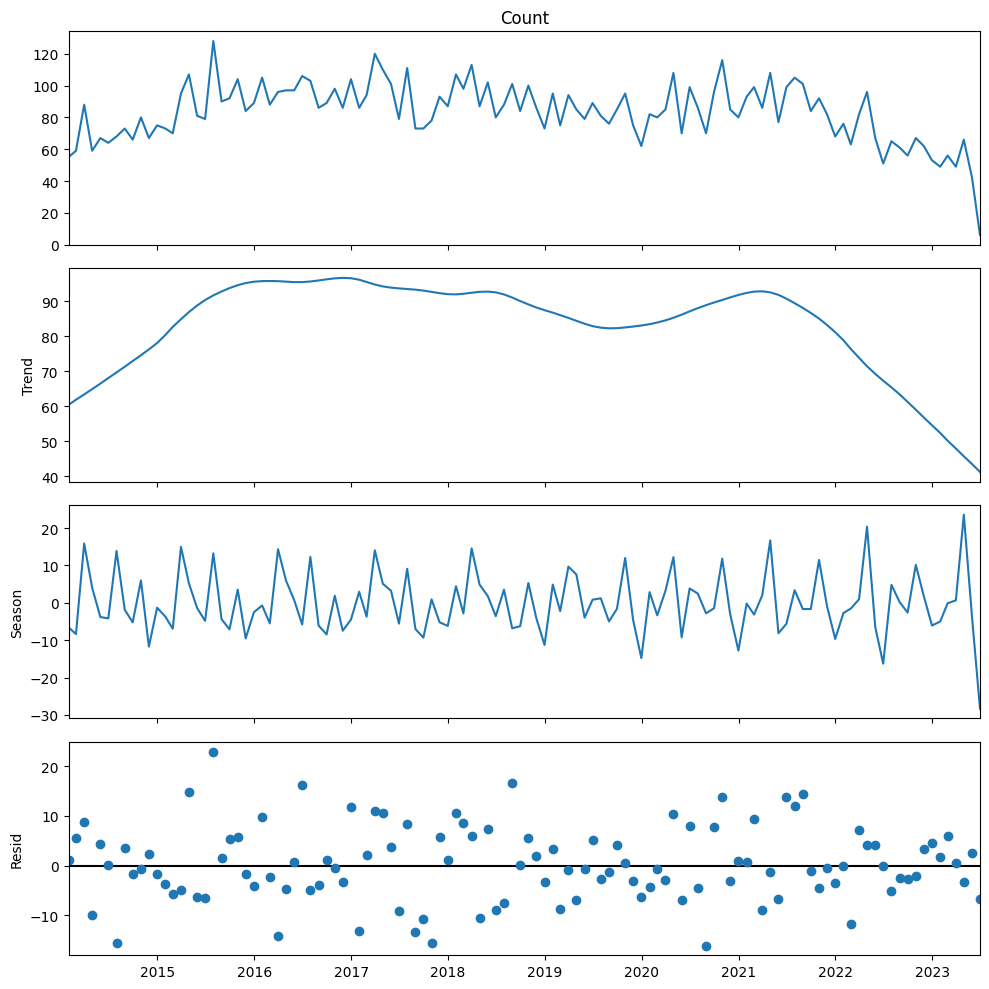

In [8]:
#Given our naive decomposition shows promise, let's go with STL since it can handle all kinds of seasonality
#We also must use additive since we have periods of zero in our data, so STL will fit the task
stl_result = STL(df['Count'].resample('M').sum()).fit()
chart = stl_result.plot()
plt.show()

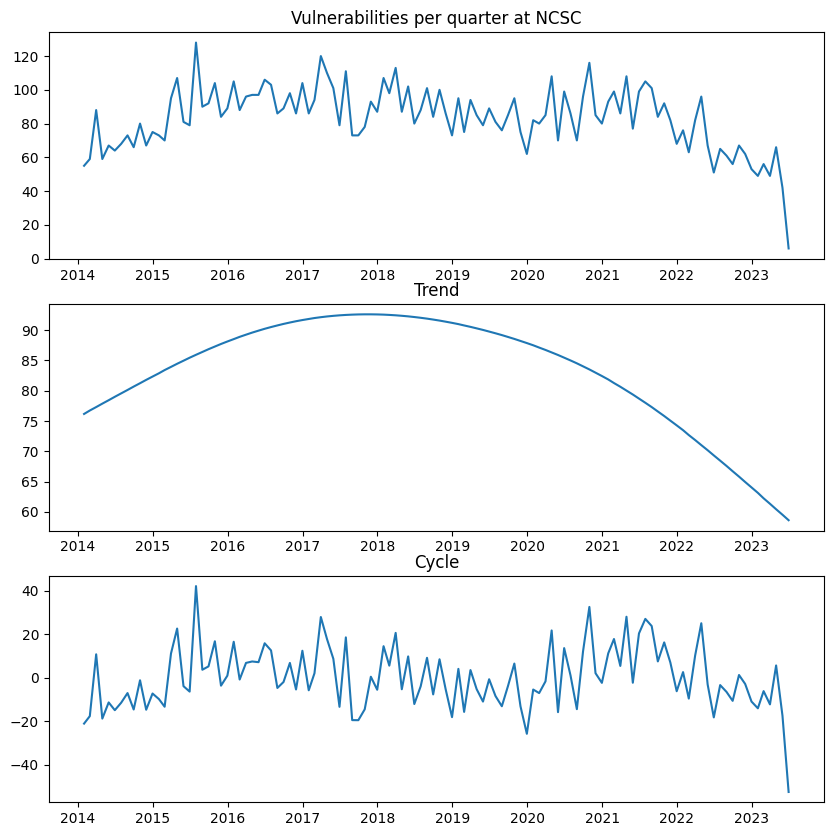

In [9]:
cycle, trend = sm.tsa.filters.hpfilter(df['Count'].resample('M').sum(), 129600) #quarterly is 1600, monthly 129600, #weekly 33177600.
fig, ax = plt.subplots(3,1)
ax[0].plot(df['Count'].resample('M').sum())
ax[0].set_title('Vulnerabilities per quarter at NCSC')
ax[1].plot(trend)
ax[1].set_title('Trend')
ax[2].plot(cycle)
ax[2].set_title('Cycle')
plt.show()

In [16]:
#cutoff = datetime.datetime(datetime.datetime.now().year-1, 12, 31, 0, 0) 
#We'll want to check our progress through the quarter so we do need that as a data set later
#check=df[df.index.tz_localize(None)>cutoff]
#df=df[df.index.tz_localize(None)<=cutoff]
# Construct the model
mod = sm.tsa.SARIMAX(df['Count'].resample('M').sum(), order=(1, 0, 0), trend='ct')
# Estimate the parameters
res = mod.fit()

print(res.summary())

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           15     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.19867D+00    |proj g|=  8.05046D-01

At iterate    5    f=  4.00504D+00    |proj g|=  3.68409D-02

At iterate   10    f=  4.00179D+00    |proj g|=  1.54085D-02

At iterate   15    f=  4.00149D+00    |proj g|=  4.87833D-03

At iterate   20    f=  4.00099D+00    |proj g|=  5.93278D-02

At iterate   25    f=  4.00039D+00    |proj g|=  8.99245D-03

At iterate   30    f=  4.00037D+00    |proj g|=  1.28685D-03

At iterate   35    f=  4.00032D+00    |proj g|=  4.99134D-03

At iterate   40    f=  3.99979D+00    |proj g|=  2.38776D-02

At iterate   45    f=  3.99705D+00    |proj g|=  2.30834D-02

At iterate   50    f=  3.99174D+00    |proj g|=  1.92666D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/opt/homebrew/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Test for trend MSE: 0.0001129618796577066


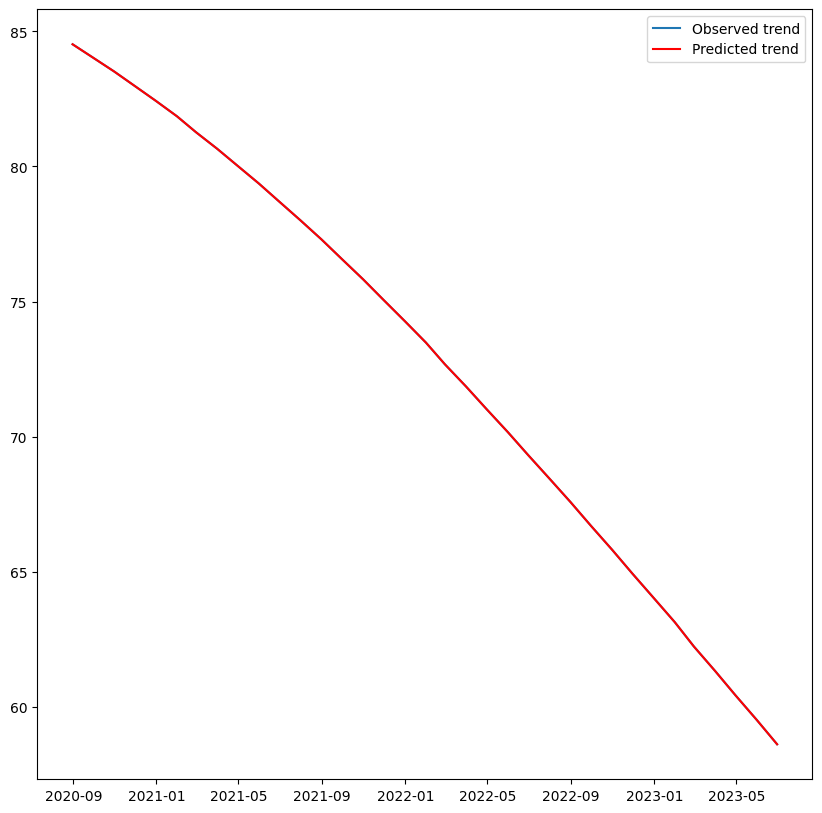

Test for cycle MSE: 16.265542747042858


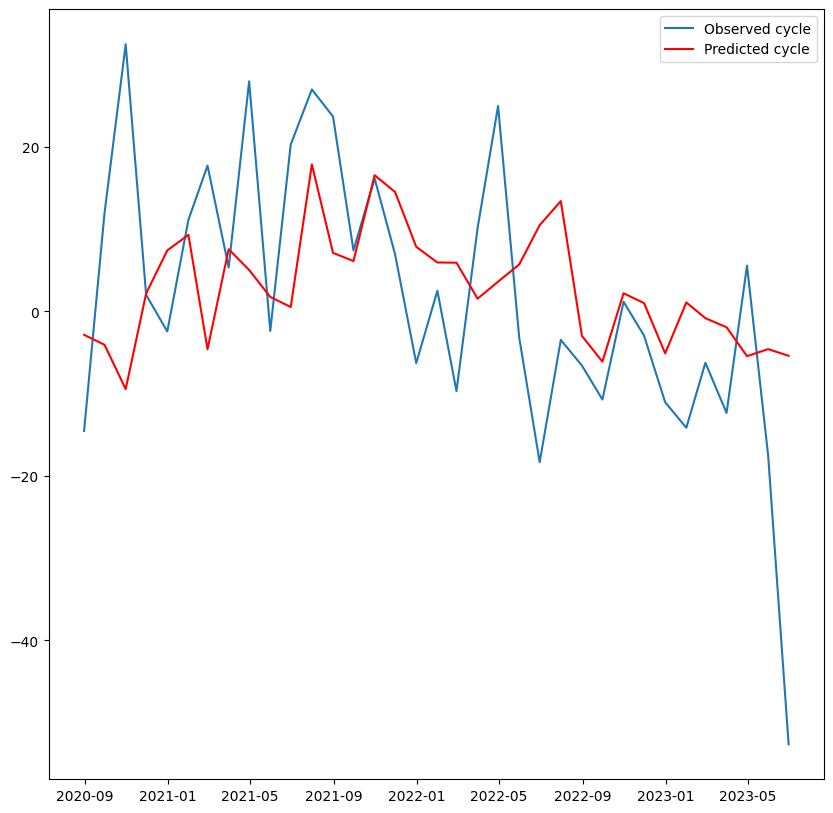

In [11]:
#Given we think it is predictable...let's try simple autoregression
component_dict = {'cycle': cycle, 'trend': trend}
prediction_results = []
for component in ['trend', 'cycle']:
    #Remove the one behind predictions
    historic = component_dict[component].iloc[:int(len(df['Count'].resample('M').sum()) * 0.7)].to_list()
    test = component_dict[component].iloc[int(len(df['Count'].resample('M').sum()) * 0.7):]
    predictions = []
    for i in range(len(test)):
        #10 here comes from our autocorrelation graph
        model = AutoReg(historic, lags=10, seasonal=True,period=4).fit()
        pred = model.predict(start=len(historic), end=len(historic), dynamic=False)
        predictions.append(pred[0])
        historic.append(test[i])
    predictions = pd.Series(predictions, index=test.index, name=component)
    prediction_results.append(predictions)
    test_score = np.sqrt(mean_squared_error(test, predictions))
    print(f'Test for {component} MSE: {test_score}')
    # plot results
    plt.plot(test.iloc[:], label='Observed '+component)
    plt.plot(predictions.iloc[:], color='red', label='Predicted '+component)
    plt.legend()
    plt.show()

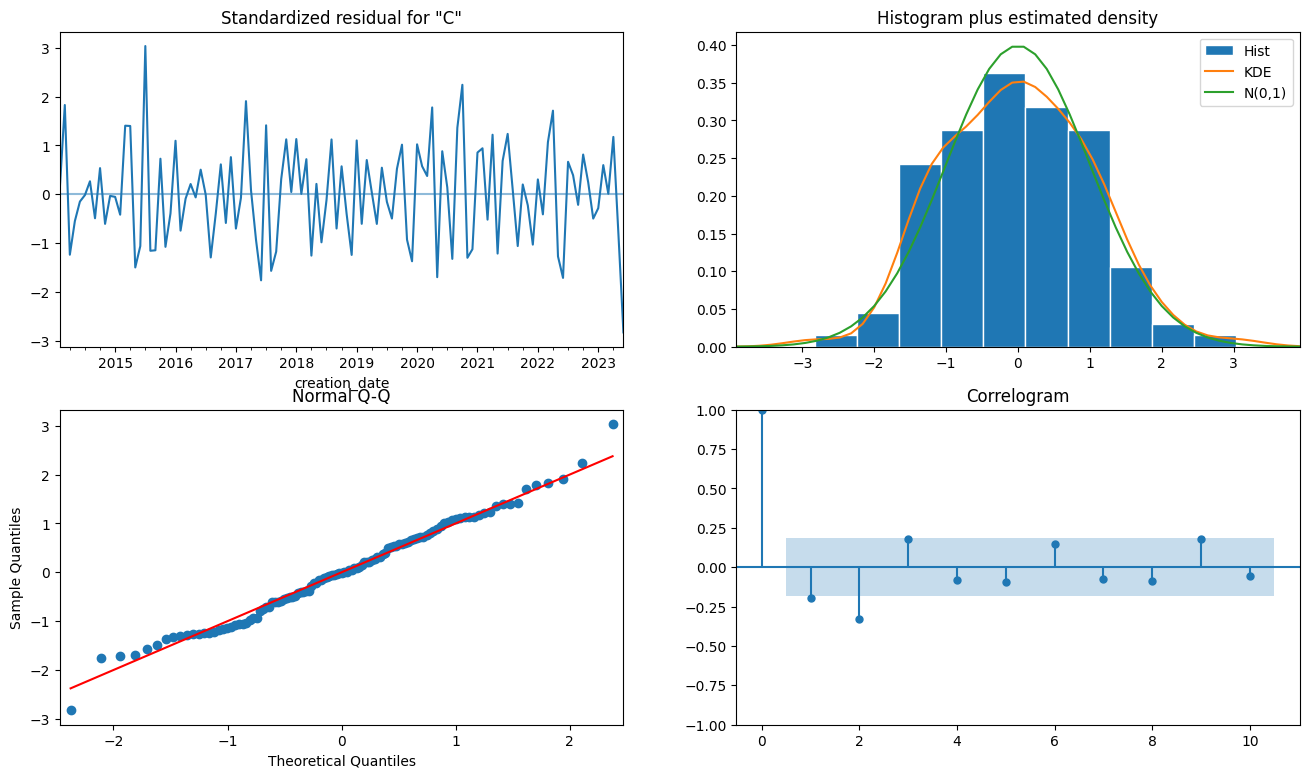

In [12]:
# Plot diagnostics
res.plot_diagnostics(figsize=(16, 9))
plt.show()

In [13]:
# Here we construct a more complete results object.
fcast_res1 = res.get_forecast(steps=1)

# Most results are collected in the `summary_frame` attribute.
# Here we specify that we want a confidence level of 90%
print(fcast_res1.summary_frame(alpha=0.10))

Count            mean    mean_se  mean_ci_lower  mean_ci_upper
2023-07-31  18.295739  15.164533      -6.647698      43.239177


In [14]:
today = date.today()
current_datetime = today.strftime("%b-%d-%Y")
#Note this format will overwrite all forecasts produced on the same day
file_name = current_datetime+"-Yearly-NCSC-vuln4cast.csv"
path = 'YearlyForecasts/'
try:
   os.makedirs(path)
except FileExistsError:
   # directory already exists
   pass
fcast_res1.summary_frame(alpha=0.10).to_csv(path+file_name)

In [15]:
#Now check how we're doing so far...
print(fcast_res1.summary_frame(alpha=0.10))
print('The current count of published NCSC vulns is: '+str(check['Count'].sum()))